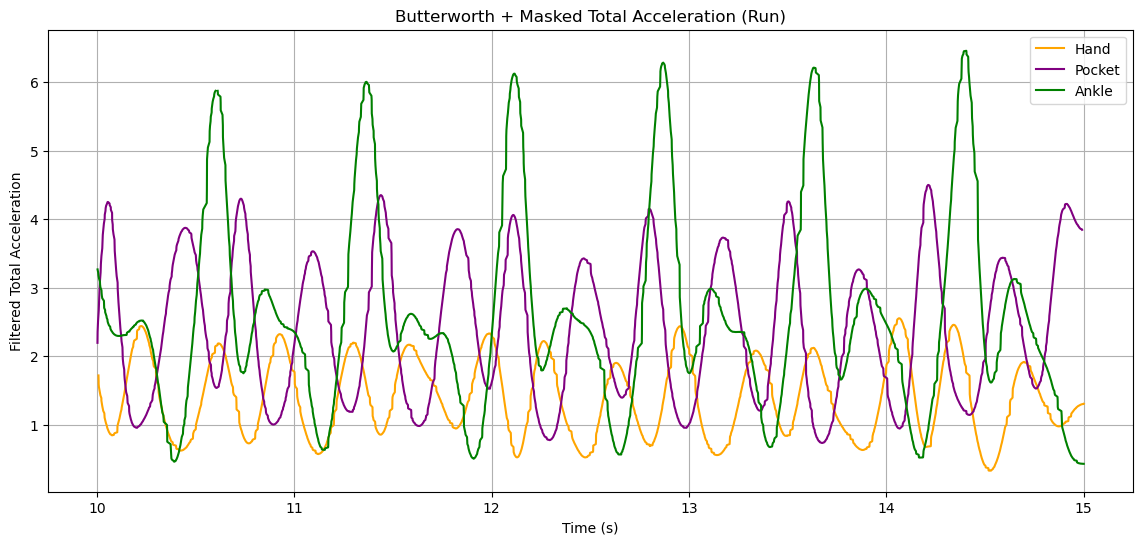

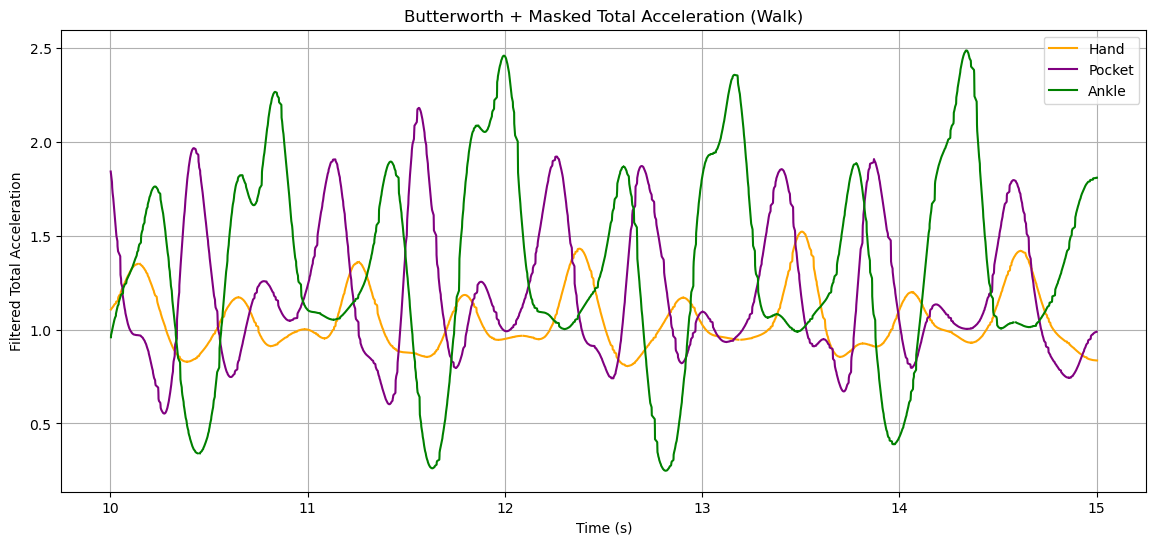

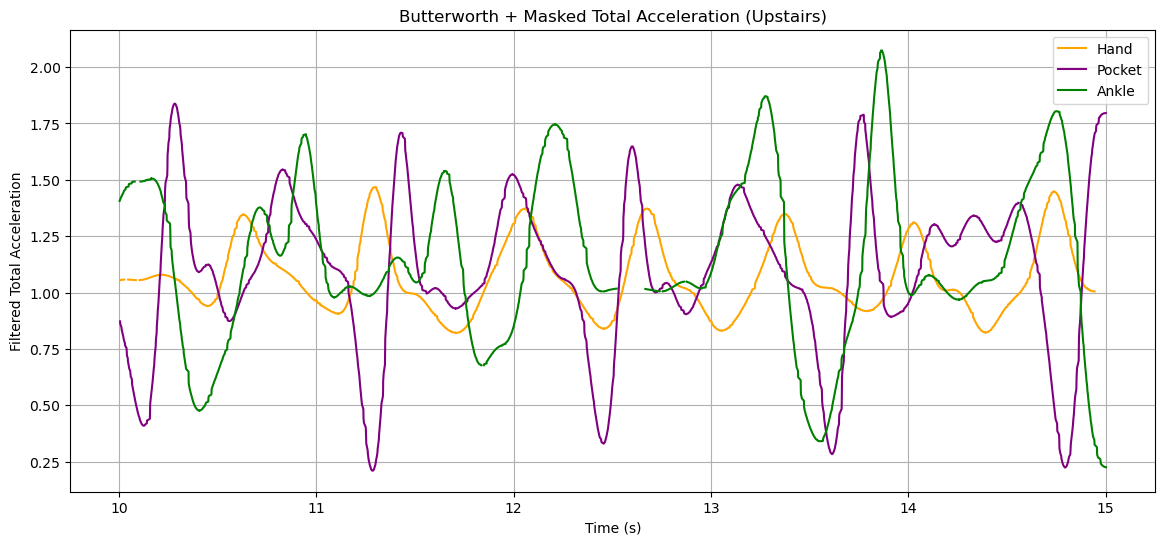

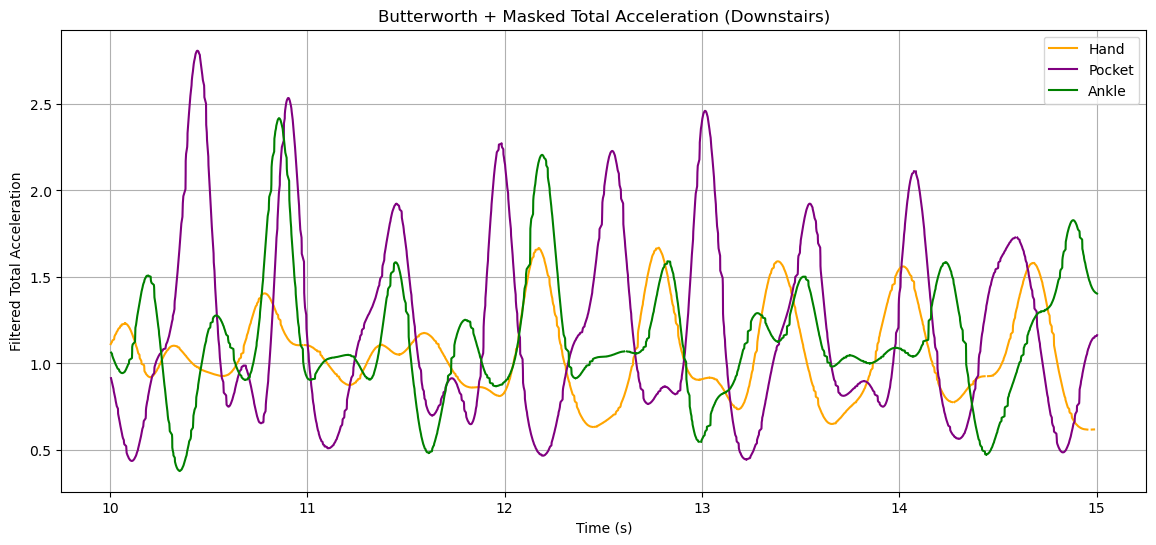

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import os

# --- Butterworth Filter ---
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# --- Mask low variation area ---
def mask_low_variation(signal, threshold=0.0001):
    grad = np.abs(np.gradient(signal))
    mask = grad > threshold
    masked_signal = signal.copy()
    masked_signal[~mask] = np.nan
    return masked_signal

# --- Process and filter each file ---
def process_filtered_signal(filename):
    df = pd.read_csv(os.path.join("data", filename))
    df['acc_total'] = np.sqrt(df['gFx']**2 + df['gFy']**2 + df['gFz']**2)
    
    # Extract 10s to 15s window
    start_time = df['time'].iloc[0] + 10
    end_time = start_time + 5
    df = df[(df['time'] >= start_time) & (df['time'] <= end_time)].reset_index(drop=True)
    
    # Sampling rate
    time_diff = np.diff(df['time'])
    fs = 1 / np.mean(time_diff) if len(time_diff) > 0 else 100
    
    # Filter and mask
    df['butter'] = butter_lowpass_filter(df['acc_total'], cutoff=5, fs=fs)
    df['butter_masked'] = mask_low_variation(df['butter'])
    
    return df['time'], df['butter_masked']

# --- Plot comparison for any movement type ---
def plot_movement_comparison(movement, title_suffix):
    placements = ['hand', 'pocket', 'ankle']
    files = [f"{movement}1-hand.csv", f"{movement}1-pocket.csv", f"{movement}1-ankle.csv"]
    colors = ['orange', 'purple', 'green']

    plt.figure(figsize=(14, 6))
    for placement, filename, color in zip(placements, files, colors):
        time, filtered = process_filtered_signal(filename)
        plt.plot(time, filtered, label=placement.capitalize(), color=color)

    plt.title(f"Butterworth + Masked Total Acceleration ({title_suffix})")
    plt.xlabel("Time (s)")
    plt.ylabel("Filtered Total Acceleration")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{movement}_comparison.png")
    plt.show()

# --- Plot for all movement types ---
plot_movement_comparison("run", "Run")
plot_movement_comparison("walk", "Walk")
plot_movement_comparison("upstair", "Upstairs")
plot_movement_comparison("downstair", "Downstairs")
